In [329]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

DTI_all=np.zeros((47, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC



In [330]:
Aging_INDICES

,sub,age,group,JND_P,group_M,group_O,group_Y
0,sub-01,25,Y,9.5600,0.0,0.0,1.0
1,sub-02,27,Y,6.6900,0.0,0.0,1.0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0
3,sub-05,21,Y,1.9500,0.0,0.0,1.0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0
5,sub-08,67,O,4.4800,0.0,1.0,0.0
6,sub-09,73,O,9.6300,0.0,1.0,0.0
7,sub-10,64,O,7.2700,0.0,1.0,0.0
8,sub-11,21,Y,1.6200,0.0,0.0,1.0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0


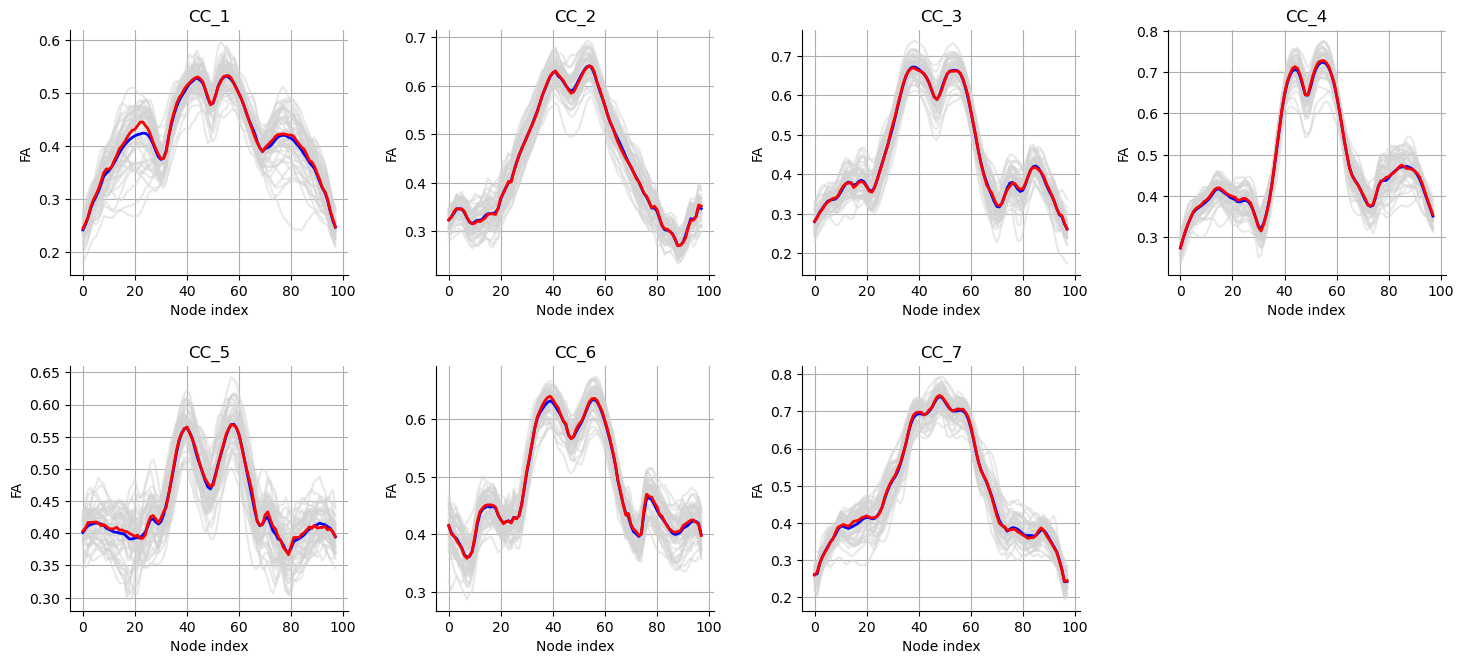

In [331]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI_all[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI_all[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



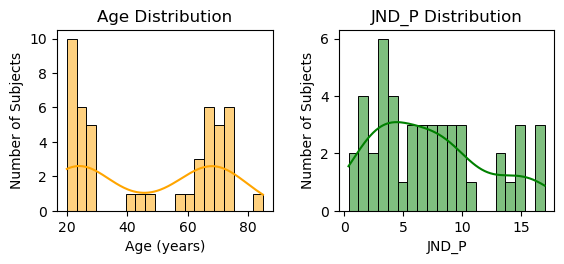

In [332]:
 # target var

import seaborn as sns

age_all = Aging_INDICES['age'].values
jnd_all = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age_all, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd_all, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)
age_all_grouped = Aging_INDICES['group_O']
jnd_all_grouped = Aging_INDICES['JND_group']

Aging_INDICES




,sub,age,group,JND_P,group_M,group_O,group_Y,JND_group
0,sub-01,25,Y,9.5600,0.0,0.0,1.0,1
1,sub-02,27,Y,6.6900,0.0,0.0,1.0,0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0,1
3,sub-05,21,Y,1.9500,0.0,0.0,1.0,0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0,0
5,sub-08,67,O,4.4800,0.0,1.0,0.0,0
6,sub-09,73,O,9.6300,0.0,1.0,0.0,1
7,sub-10,64,O,7.2700,0.0,1.0,0.0,1
8,sub-11,21,Y,1.6200,0.0,0.0,1.0,0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0,0


Feat selectio based on simple lin regression using f_regression

CC 1 - Best features for JND: [76 75 77 74 78 86 85 84  5 82]
CC 1 - Best features for Age: [15 16 14 17 13 12 18 74 75 11]
CC 2 - Best features for JND: [ 7  9 13 12  8 10 11 85 84 72]
CC 2 - Best features for Age: [10  9 12 72 70 71 69 88 83 73]
CC 3 - Best features for JND: [14 13 12 15 22 23 21 24 11 67]
CC 3 - Best features for Age: [41 42 40 43 23 14 66 24 22 39]
CC 4 - Best features for JND: [70 57 56 69 45 54 44 55 78 71]
CC 4 - Best features for Age: [77 78 76 70 69 79  7 75  6  8]
CC 5 - Best features for JND: [73 74 59 58 15 42 16 60 56 41]
CC 5 - Best features for Age: [73 74 75 72 10 11 12 13 88  8]
CC 6 - Best features for JND: [52 75 86 51 85 84 53 87 88 50]
CC 6 - Best features for Age: [82 83 81 84 85 80 15 79 87 16]
CC 7 - Best features for JND: [42 41 53 38 37 40 43 52 36 54]
CC 7 - Best features for Age: [32 30 22 24 31  0 33 23 29 17]


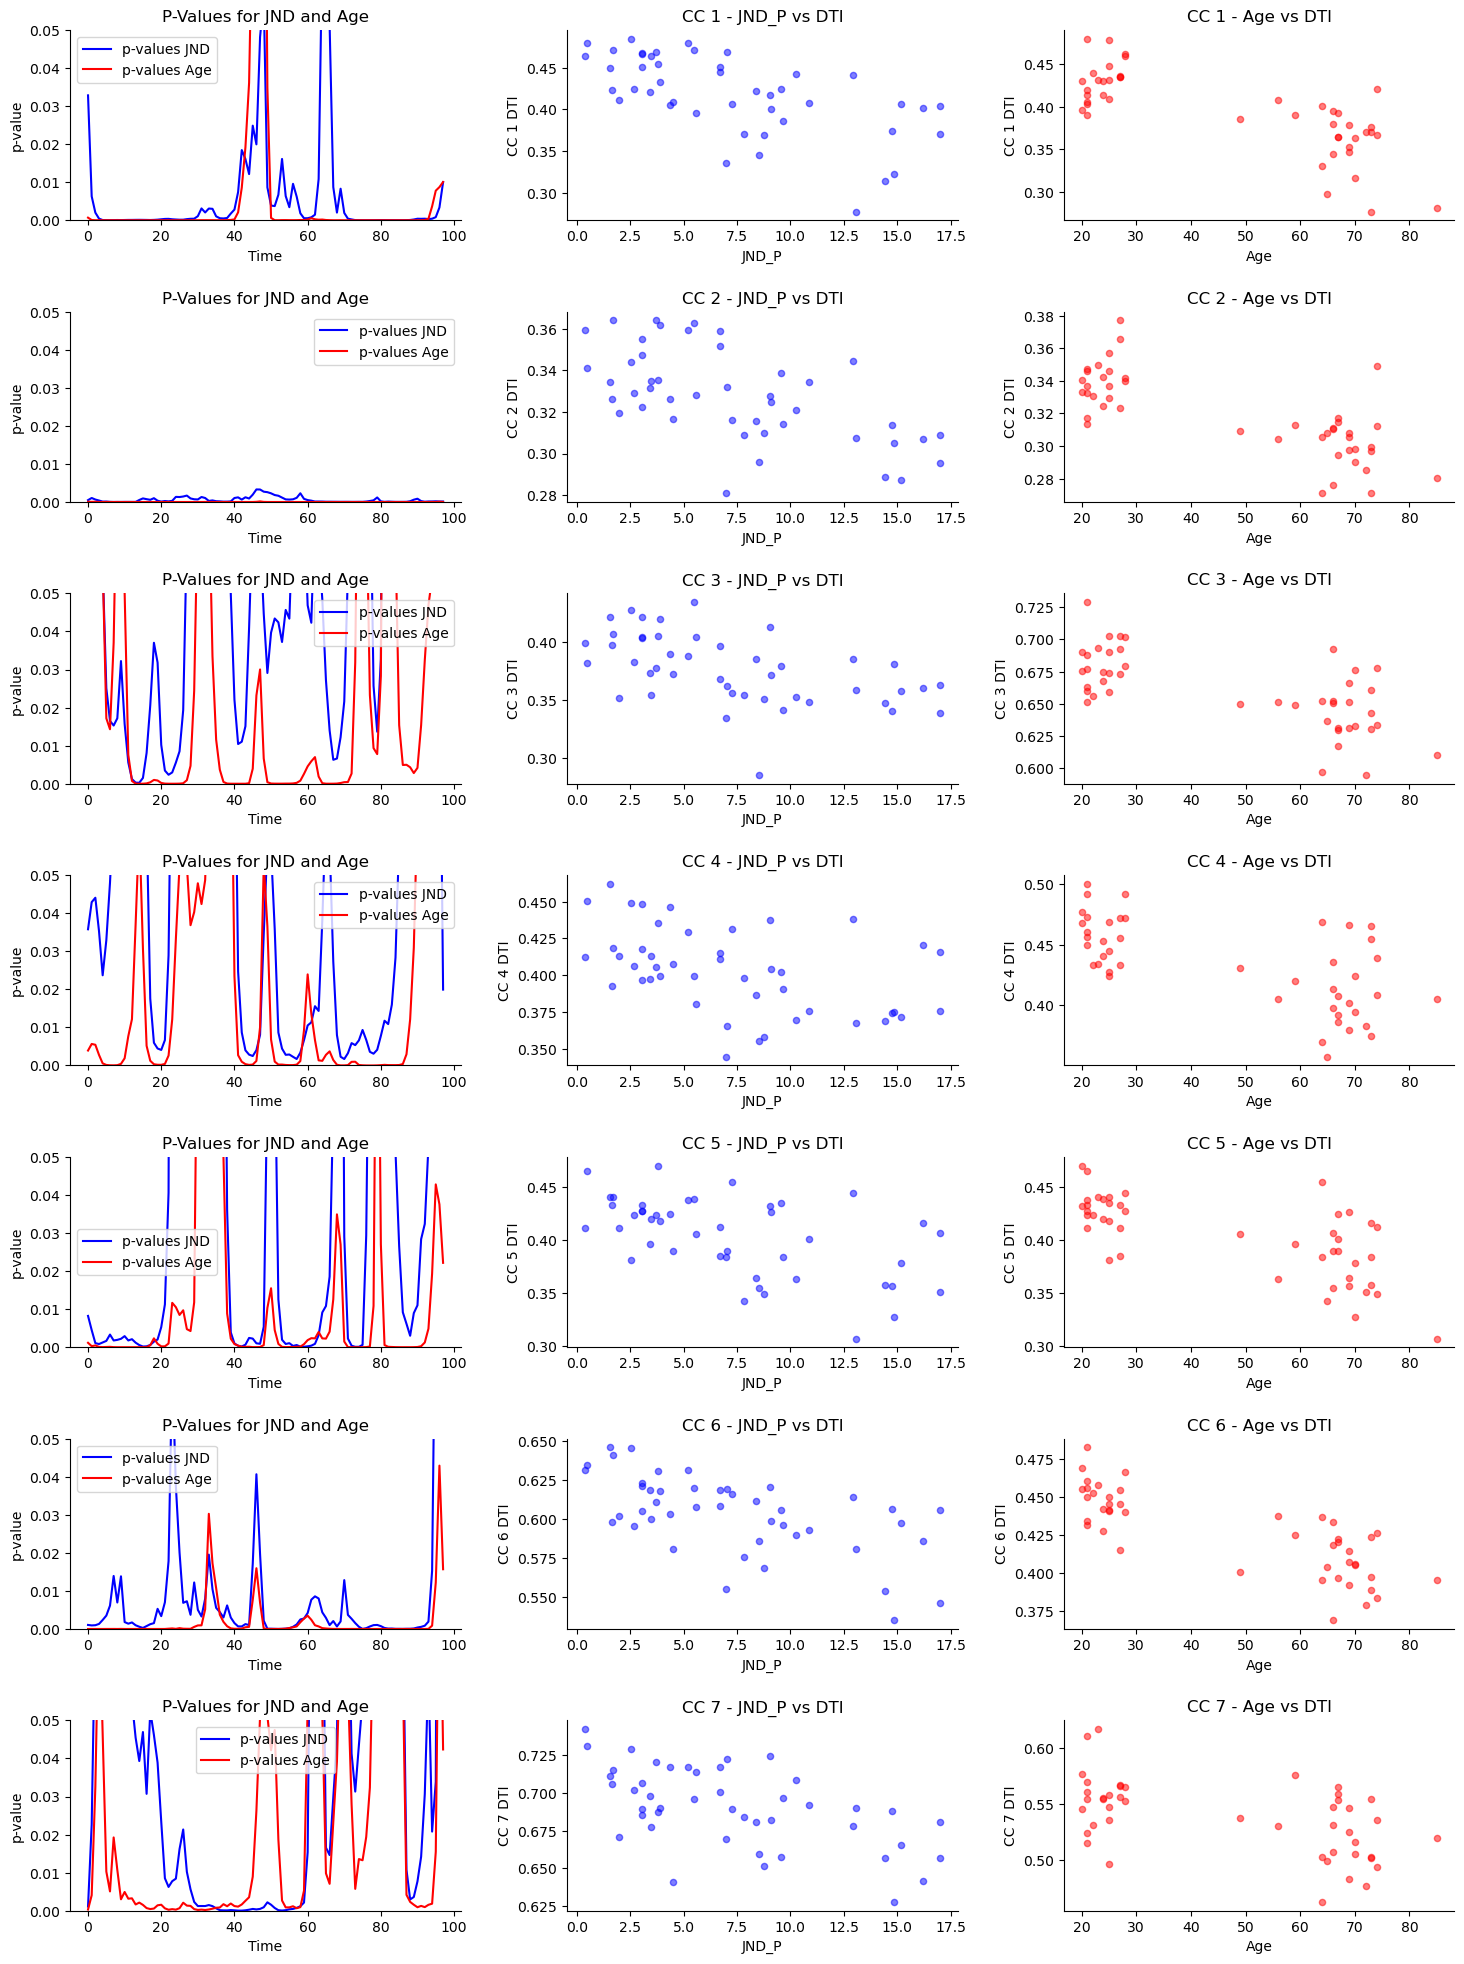

In [552]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

for cc in range(1,8):
        
    f_statistic, p_values_jnd = f_regression(DTI[:,:,cc-1], jnd )
    f_statistic, p_values_age = f_regression(DTI[:,:,cc-1], age )

    best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    best_features_age_cc = np.argsort(p_values_age)[:97]
    print(f'CC {cc} - Best features for JND: {best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {best_features_age_cc[:10]}')
    best_features_jnd_cc_allCC[cc-1,:]= best_features_jnd_cc[:10]
    best_features_age_cc_allCC[cc-1,:] = best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.05)
    axs[cc-1,0].set_xlabel('Time')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=best_features_age_cc[0]  # on prend la feature la plus significative pour Age
    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



In [557]:
best_features_jnd_cc_allCC[0,:].tolist()

[76, 75, 77, 74, 78, 86, 85, 84, 5, 82]

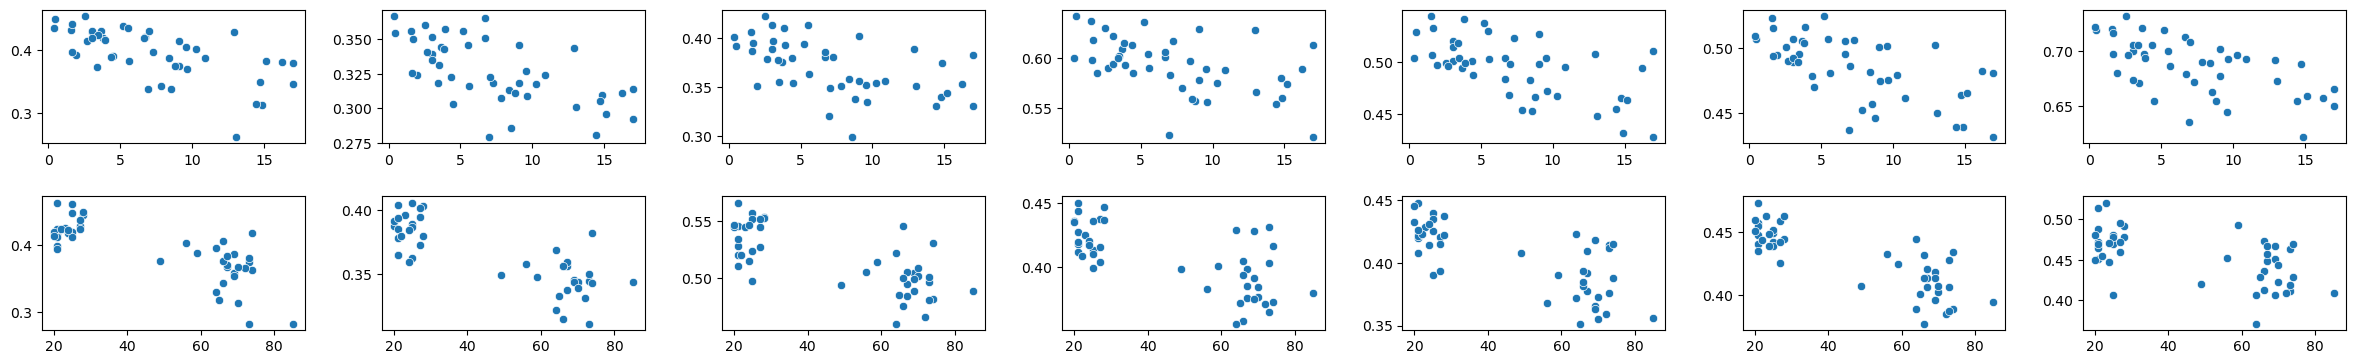

In [568]:
fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,4))

for cc in range(7):
    sns.scatterplot(y=DTI[:,best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc]) 
    sns.scatterplot(y=DTI[:,best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc])

plt.tight_layout(pad=2.0)

Random state for reproducibility: 42
Processing target age CC 1
RFE : Processing target age CC 1
Processing target jnd CC 1
RFE : Processing target jnd CC 1
Random state for reproducibility: 42
Processing target age CC 2
RFE : Processing target age CC 2
Processing target jnd CC 2
RFE : Processing target jnd CC 2
Random state for reproducibility: 42
Processing target age CC 3
RFE : Processing target age CC 3
Processing target jnd CC 3
RFE : Processing target jnd CC 3
Random state for reproducibility: 42
Processing target age CC 4
RFE : Processing target age CC 4
Processing target jnd CC 4
RFE : Processing target jnd CC 4
Random state for reproducibility: 42
Processing target age CC 5
RFE : Processing target age CC 5
Processing target jnd CC 5
RFE : Processing target jnd CC 5
Random state for reproducibility: 42
Processing target age CC 6
RFE : Processing target age CC 6
Processing target jnd CC 6
RFE : Processing target jnd CC 6
Random state for reproducibility: 42
Processing target age

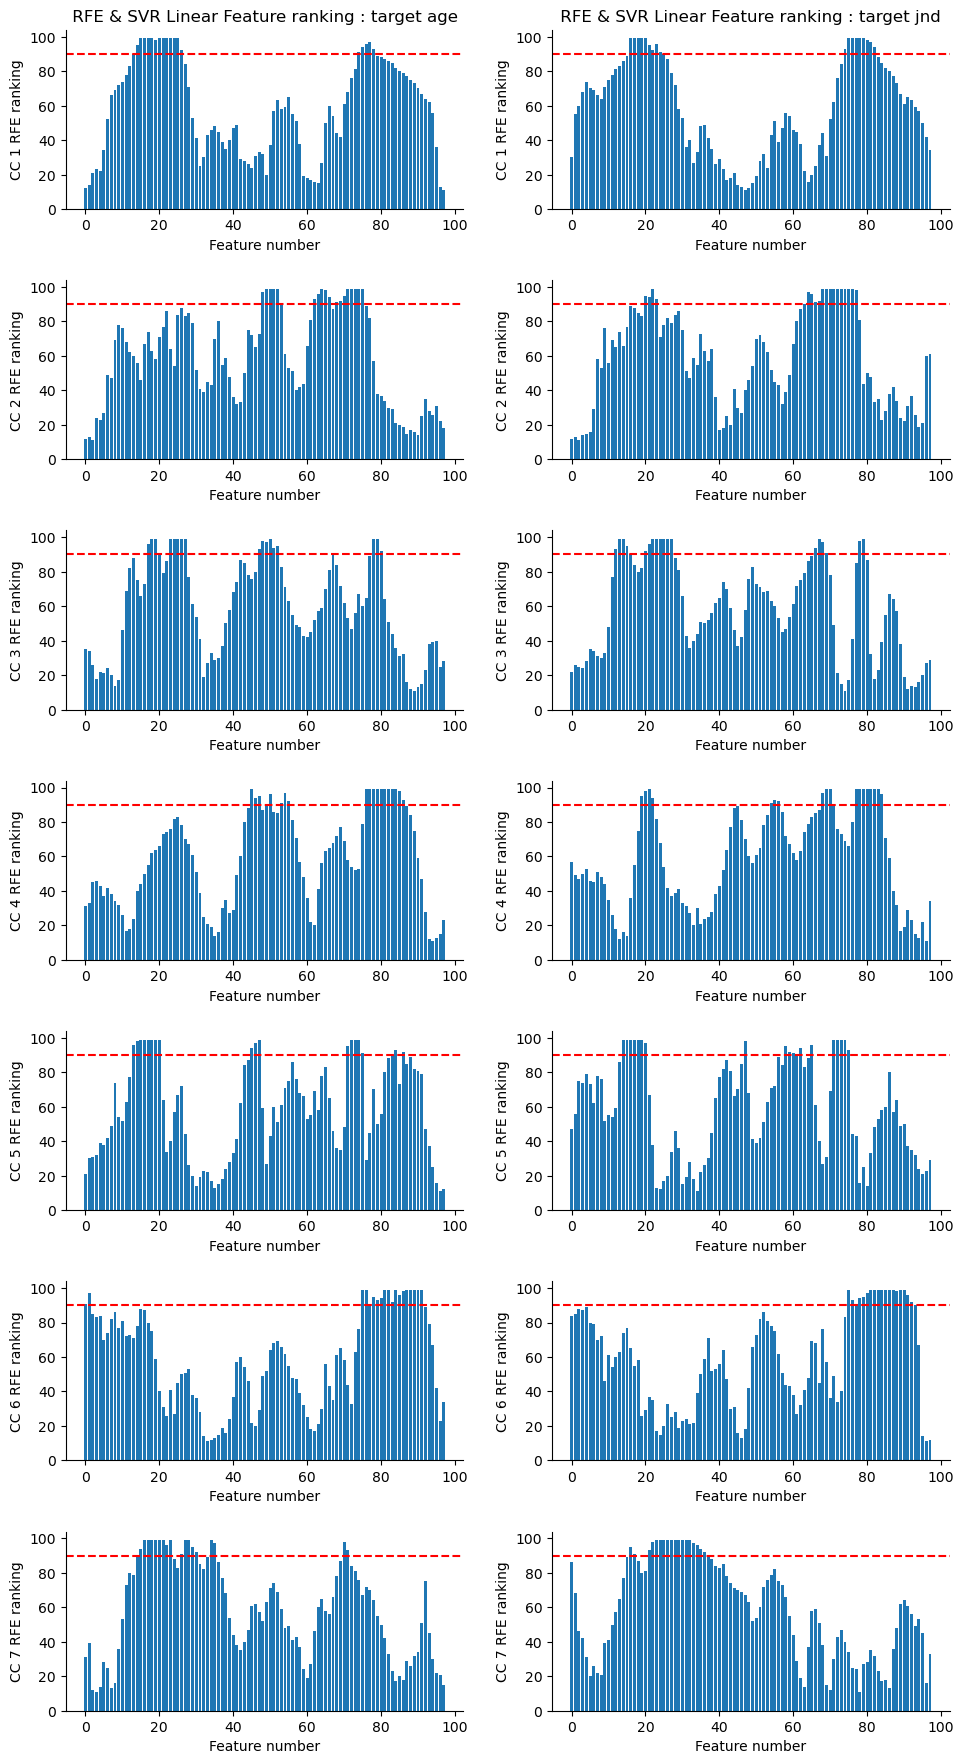

In [405]:

figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(10, 18))
RFE_ranked_feat_allCC_tgt=[[] for _ in range(7)]

for cc in range(1,8):
    RFE_ranked_feat_CC_tgt=[]

    dti_matrix = DTI[:,:,cc-1]  

    datatest = pd.DataFrame()

    # Ajouter les colonnes de DTI (remplacez par vos données réelles)
    for i in range(dti_matrix.shape[1]):
        datatest[f'cc{cc-1}_{i+1}'] = dti_matrix[:, i]

    random_state=42 #np.random.randint(0,100)
    print(f'Random state for reproducibility: {random_state}')

    target=['age','jnd']


    for t in target:
        if t=='age':
            y=age
            axsy=0
        elif t=='jnd':
            y=jnd
            axsy=1
        ranked_feat_allCC=[]

        print(f'Processing target {t} CC {cc}')
        X=datatest    # Features (independent variable)
            
        # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

        scaler = StandardScaler()
        # X_train_scaled = scaler.fit_transform(X_train)
        # X_test_scaled = scaler.transform(X_test)
        X_scaled = scaler.fit_transform(X)
        if t=='jnd':
            estimator = SVR(kernel="linear")
        elif t=='age':
            estimator = LogisticRegression()

        selector = RFE(estimator, n_features_to_select=10, step=1)
        print(f'RFE : Processing target {t} CC {cc}')

        # selector = selector.fit(X_train, y_train)
        selector = selector.fit(X, y)

        selector.support_
        selector.ranking_
        ranked_feat_allCC.append(selector.ranking_)

        np.where(selector.ranking_<10)[0].tolist()
        
        axs[cc-1, axsy].bar(np.arange(98), 100-selector.ranking_)
        axs[cc-1, axsy].axhline(90, color='red', linestyle='--')  
        axs[cc-1, axsy].set_xlabel("Feature number")
        axs[cc-1, axsy].set_ylabel(f'CC {cc} RFE ranking') 
        axs[cc-1, axsy].spines['top'].set_visible(False)
        axs[cc-1, axsy].spines['right'].set_visible(False)

        axs[0, axsy].set_title(f' RFE & SVR Linear Feature ranking : target {t} ')
        plt.tight_layout(pad=2.0)

        RFE_ranked_feat_CC_tgt.append(ranked_feat_allCC)

    RFE_ranked_feat_allCC_tgt[cc-1].append(RFE_ranked_feat_CC_tgt)


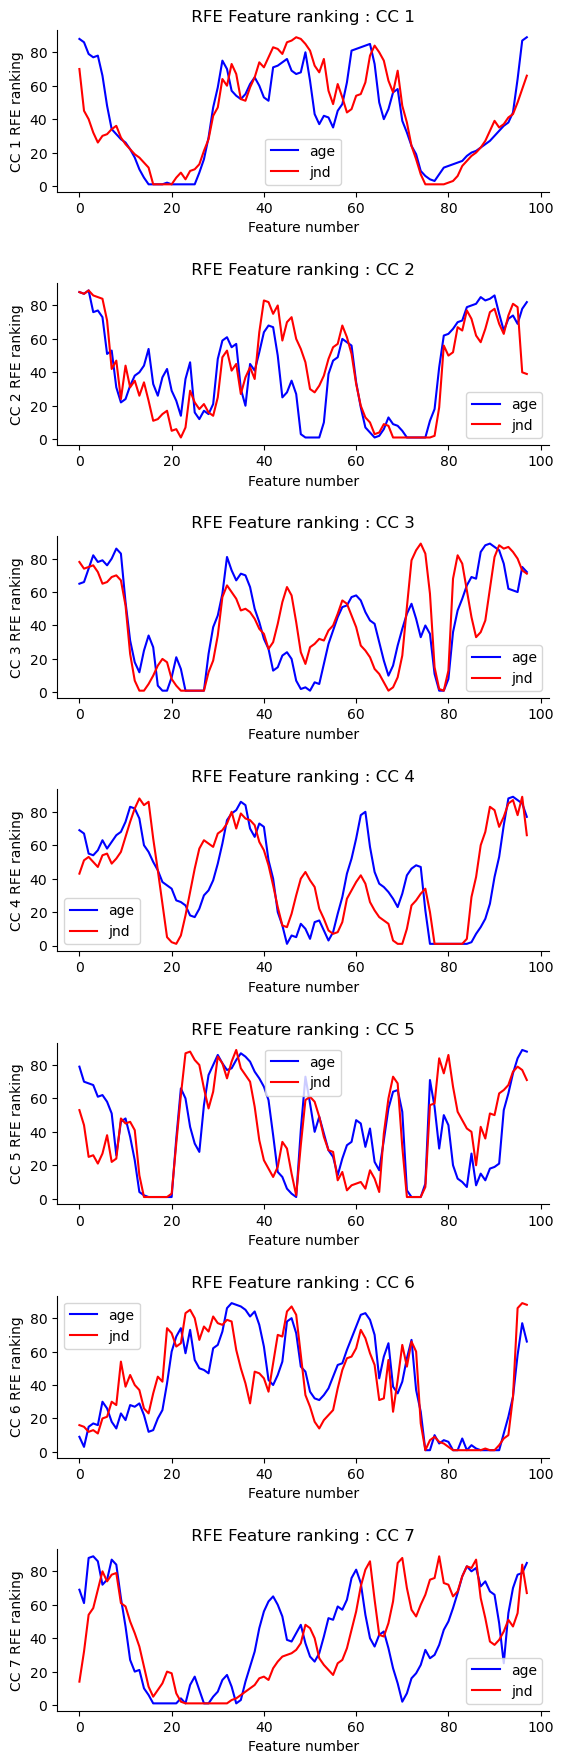

In [406]:
fig, axs = plt.subplots(nrows=7, ncols=1, figsize=(6, 18))
for cc in range(7):
            
    tgt_idx=0
    axs[cc].plot(RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0].tolist(),'blue')
    tgt_idx=1
    axs[cc].plot(RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0].tolist(),'red')
    axs[cc].set_ylabel(f'CC {cc+1} RFE ranking')
    axs[cc].spines['top'].set_visible(False)
    axs[cc].spines['right'].set_visible(False)
    axs[cc].legend(['age','jnd'])
    axs[cc].set_title(f' RFE Feature ranking : CC {cc+1} ')
  

    axs[cc].set_xlabel("Feature number")

plt.tight_layout(pad=2.0)

create an array Xbest with the x best features of each CC

RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]

In [407]:
cc=6
tgt_idx=0
np.where(RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]<2)[0].tolist() 


RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]<2
matrice=DTI[:,RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]<2,cc]
matrice.shape

(42, 10)

In [ ]:
RFE_selected_all_cc_age=np.zeros((7,10  ))
RFE_selected_all_cc_jnd=np.zeros((7,10  ))
for cc in range(7):
    RFE_selected_all_cc_age[cc,:]=np.where(RFE_ranked_feat_allCC_tgt[cc][0][0][0]<2)[0].tolist()
    RFE_selected_all_cc_jnd[cc,:]=np.where(RFE_ranked_feat_allCC_tgt[cc][0][1][0]<2)[0].tolist()


# RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]

CC 1 : [15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
CC 2 : [49, 50, 51, 52, 64, 71, 72, 73, 74, 75]
CC 3 : [18, 19, 23, 24, 25, 26, 27, 50, 78, 79]
CC 4 : [45, 76, 77, 78, 79, 80, 81, 82, 83, 84]
CC 5 : [15, 16, 17, 18, 19, 20, 47, 72, 73, 74]
CC 6 : [75, 76, 81, 82, 84, 87, 88, 89, 90, 91]
CC 7 : [16, 17, 18, 19, 20, 21, 23, 27, 28, 34]
CC 1 : [16, 17, 18, 19, 20, 75, 76, 77, 78, 79]
CC 2 : [22, 68, 69, 70, 71, 72, 73, 74, 75, 76]
CC 3 : [13, 14, 22, 23, 24, 25, 26, 27, 67, 79]
CC 4 : [21, 69, 70, 77, 78, 79, 80, 81, 82, 83]
CC 5 : [14, 15, 16, 17, 18, 19, 71, 72, 73, 74]
CC 6 : [75, 81, 82, 83, 84, 85, 86, 87, 89, 90]
CC 7 : [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


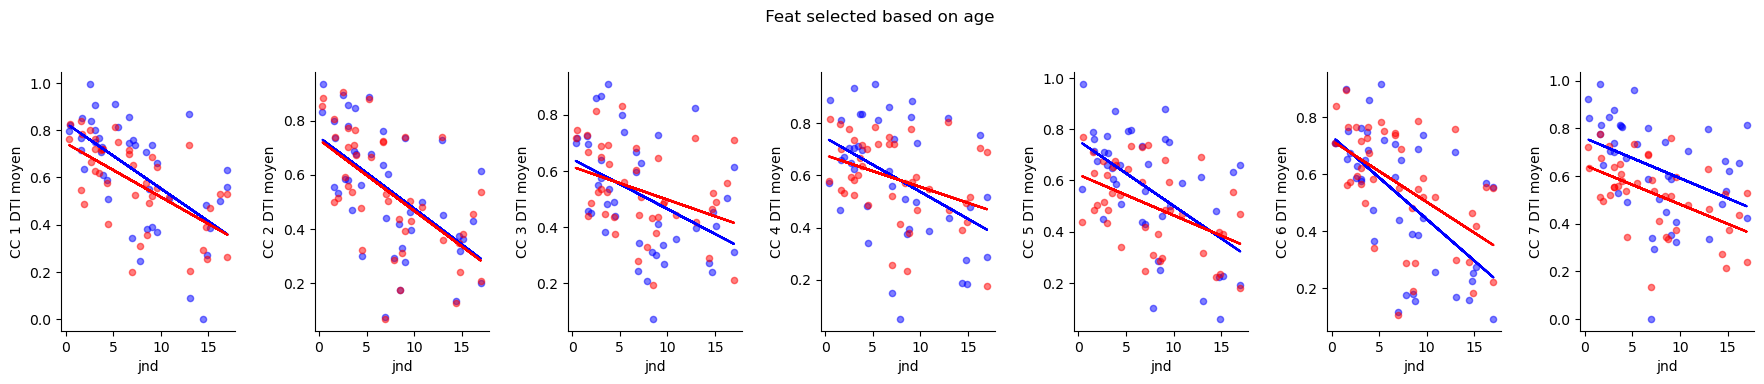

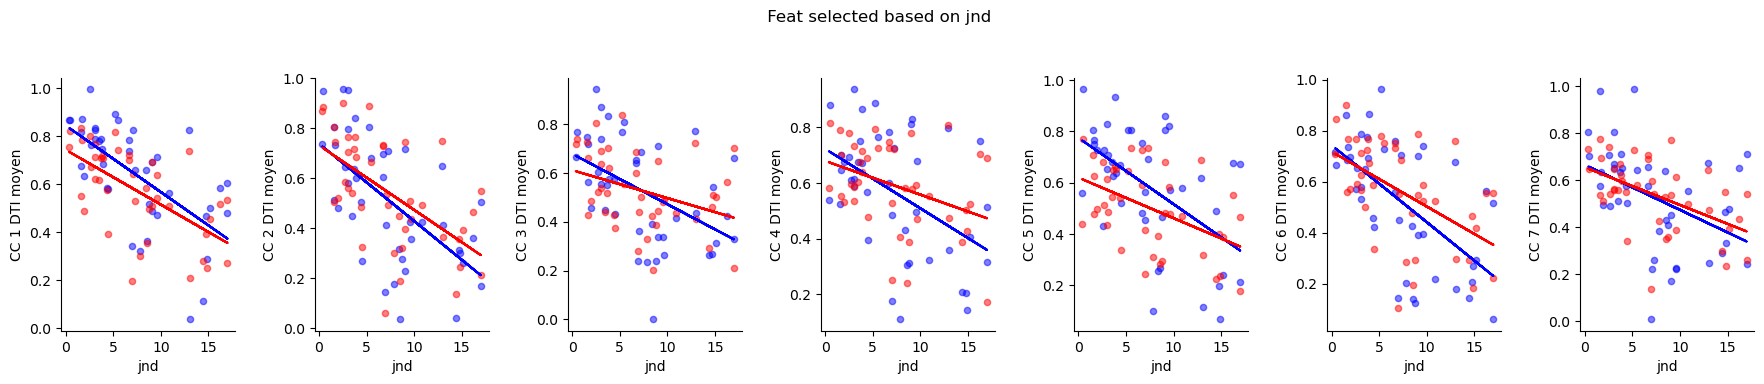

In [423]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

tgt_str=['age','jnd']
tgtid=1

for tgt_feat in range(2):

    if tgt_feat==0:
        featselstr='age'
    elif tgt_feat==1:
        featselstr='jnd'

    tgt_str[tgtid]  # age
    if tgtid==0:
        tgt=age
    elif tgtid==1:
        tgt=jnd
  

    scaler = MinMaxScaler()

    fig, axs = plt.subplots(nrows=1, ncols=7, figsize=(18,4))

    for cc in range(1,8):

        X_scaled=scaler.fit_transform(DTI[:,:,cc-1])
        feat_selected=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][tgt_feat][0]<2)[0].tolist()
        feat_non_selected=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][tgt_feat][0]>=2)[0].tolist()

        print(f'CC {cc} : {np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][tgt_feat][0]<2)[0].tolist()}')
        # print(f'CC {cc} : {feat_selected}')

        # axs[cc-1].plot(tgt, np.mean(X_scaled[:,feat_selected],axis=1),'b.')
        # axs[cc-1].plot(tgt, np.mean(X_scaled[:,feat_non_selected],axis=1),'r.')

        x=tgt
        y1=np.mean(X_scaled[:,feat_selected],axis=1)
        y2=np.mean(X_scaled[:,feat_non_selected],axis=1)

        x = sm.add_constant(x)

        # Créer le modèle de régression linéaire
        model1 = sm.OLS(y1, x)
        model2= sm.OLS(y2, x)

        # Ajuster le modèle aux données
        results1 = model1.fit()
        results2 = model2.fit()
        # print(results1.summary())

        slope1 = results1.params[1]
        intercept1 = results1.params[0]
        slope2 = results2.params[1]
        intercept2 = results2.params[0]

        # Créer une ligne de régression
        regression_line1 = slope1 * x[:, 1] + intercept1
        regression_line2 = slope2 * x[:, 1] + intercept2

        # Tracer les points de données
        axs[cc-1].scatter(x[:, 1], y1, color='blue', label='Données', alpha=0.5, s=20)
        axs[cc-1].scatter(x[:, 1], y2, color='red', label='Données', alpha=0.5, s=20)
        # Tracer la ligne de régression
        axs[cc-1].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
        axs[cc-1].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')
        axs[cc-1].set_xlabel(tgt_str[tgtid])
        axs[cc-1].set_ylabel(f'CC {cc} DTI moyen')
        axs[cc-1].spines['top'].set_visible(False)
        axs[cc-1].spines['right'].set_visible(False)

    fig.suptitle(f' Feat selected based on {featselstr}  ')

    plt.tight_layout(pad=2.0)
        # Afficher le graphique




CC 1 : [15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
CC 1 : [16, 17, 18, 19, 20, 75, 76, 77, 78, 79]
CC 2 : [49, 50, 51, 52, 64, 71, 72, 73, 74, 75]
CC 2 : [22, 68, 69, 70, 71, 72, 73, 74, 75, 76]
CC 3 : [18, 19, 23, 24, 25, 26, 27, 50, 78, 79]
CC 3 : [13, 14, 22, 23, 24, 25, 26, 27, 67, 79]
CC 4 : [45, 76, 77, 78, 79, 80, 81, 82, 83, 84]
CC 4 : [21, 69, 70, 77, 78, 79, 80, 81, 82, 83]
CC 5 : [15, 16, 17, 18, 19, 20, 47, 72, 73, 74]
CC 5 : [14, 15, 16, 17, 18, 19, 71, 72, 73, 74]
CC 6 : [75, 76, 81, 82, 84, 87, 88, 89, 90, 91]
CC 6 : [75, 81, 82, 83, 84, 85, 86, 87, 89, 90]
CC 7 : [16, 17, 18, 19, 20, 21, 23, 27, 28, 34]
CC 7 : [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


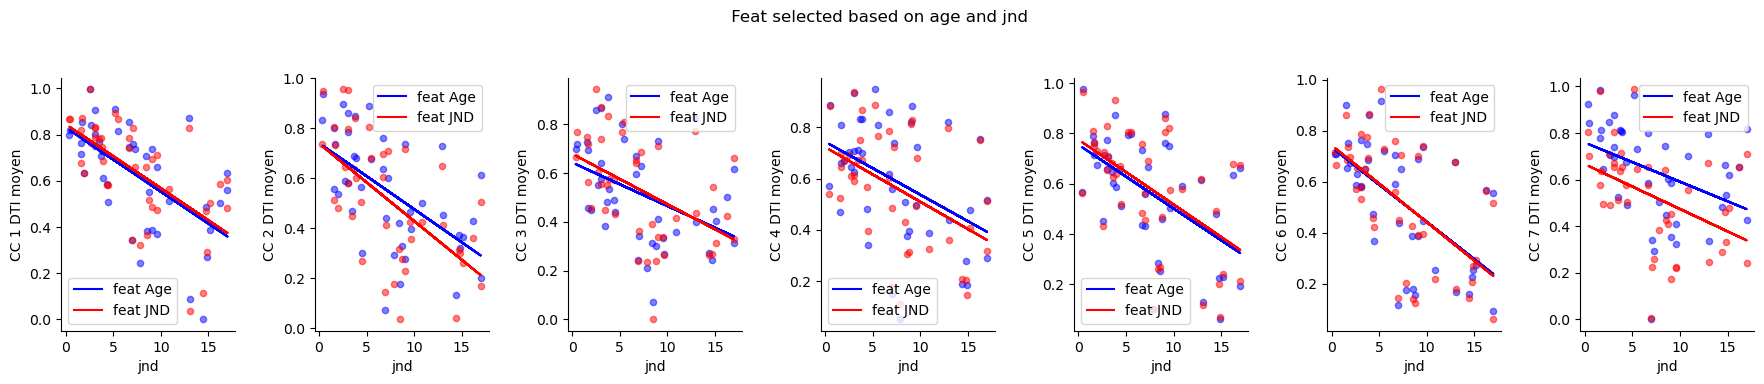

In [433]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

tgt_str=['age','jnd']
tgtid=1

# for tgt_feat in range(2):

if tgt_feat==0:
    featselstr='age'
elif tgt_feat==1:
    featselstr='jnd'

tgt_str[tgtid]  # age
if tgtid==0:
    tgt=age
elif tgtid==1:
    tgt=jnd


scaler = MinMaxScaler()

fig, axs = plt.subplots(nrows=1, ncols=7, figsize=(18,4))

for cc in range(1,8):

    X_scaled=scaler.fit_transform(DTI[:,:,cc-1])
    feat_selected_age=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][0][0]<2)[0].tolist()
    feat_non_selected_age=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][0][0]>=2)[0].tolist()

    feat_selected_jnd=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][1][0]<2)[0].tolist()
    feat_non_selected_jnd=np.where(RFE_ranked_feat_allCC_tgt[cc-1][0][1][0]>=2)[0].tolist()

    print(f'CC {cc} : {feat_selected_age}')
    print(f'CC {cc} : {feat_selected_jnd}')

    # print(f'CC {cc} : {feat_selected}')

    # axs[cc-1].plot(tgt, np.mean(X_scaled[:,feat_selected],axis=1),'b.')
    # axs[cc-1].plot(tgt, np.mean(X_scaled[:,feat_non_selected],axis=1),'r.')

    x=tgt
    y1=np.mean(X_scaled[:,feat_selected_age],axis=1)
    y2=np.mean(X_scaled[:,feat_selected_jnd],axis=1)

    x = sm.add_constant(x)

    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)

    # Ajuster le modèle aux données
    results1 = model1.fit()
    results2 = model2.fit()
    # print(results1.summary())

    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2

    # Tracer les points de données
    axs[cc-1].scatter(x[:, 1], y1, color='blue', alpha=0.5, s=20)
    axs[cc-1].scatter(x[:, 1], y2, color='red', alpha=0.5, s=20)
    # Tracer la ligne de régression
    axs[cc-1].plot(x[:, 1], regression_line1, color='blue', label='feat Age')
    axs[cc-1].plot(x[:, 1], regression_line2, color='red', label='feat JND')
    axs[cc-1].legend()
    axs[cc-1].set_xlabel(tgt_str[tgtid])
    axs[cc-1].set_ylabel(f'CC {cc} DTI moyen')
    axs[cc-1].spines['top'].set_visible(False)
    axs[cc-1].spines['right'].set_visible(False)

fig.suptitle(f' Feat selected based on age and jnd  ')

plt.tight_layout(pad=2.0)
    # Afficher le graphique




In [347]:
allbestfeat_cc=[[],[]]
last10from70_DTI=np.zeros((2,10))
matrice_finale=np.zeros((2, 42, 70)) # 2 targets x 47 subjects x 70 features (10 features x 7 CC)
for tgt_idx, tgt in enumerate(target):

    if tgt=='age':
        y=age

    elif tgt=='jnd':
        y=jnd

    matrices = [DTI[:,RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]<2,cc] for _ in range(7)]  # Exemple avec des matrices aléatoires
    

    for cc in range(7):
        allbestfeat_cc[tgt_idx].append(np.where(RFE_ranked_feat_allCC_tgt[cc][0][tgt_idx][0]<2)[0].tolist())

    matrice_finale[tgt_idx] = np.hstack(matrices)
    matrice_finale.shape

   
    X=matrice_finale[tgt_idx]    # Features (independent variable)
            
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

    scaler = StandardScaler()
    X_scaled=scaler.fit_transform(X)
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_test_scaled = scaler.transform(X_test)

    # if t=='jnd':
    
    estimator = SVR(kernel="linear")    
    # estimator = XGBRegressor()   

    
    selector = RFE(estimator, n_features_to_select=10, step=1)
    print(f'RFE from SVR linear for JND: Processing target {tgt} ')

    selector = selector.fit(X_scaled, y)

    last10from70_DTI[tgt_idx,:]=np.where(selector.ranking_<2)[0].tolist()
 


    # sns.scatterplot(x=y, y=X_scaled[:,31])
    # plt.show()

print(last10from70_DTI)
matrice_finale.shape
allbestfeat_cc[1]


RFE from SVR linear for JND: Processing target age 
RFE from SVR linear for JND: Processing target jnd 
[[29. 39. 45. 49. 50. 55. 59. 60. 65. 69.]
 [ 8. 18. 20. 32. 37. 42. 43. 52. 57. 62.]]


[[23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
 [16, 17, 18, 19, 20, 75, 76, 77, 78, 79],
 [22, 68, 69, 70, 71, 72, 73, 74, 75, 76],
 [13, 14, 22, 23, 24, 25, 26, 27, 67, 79],
 [21, 69, 70, 77, 78, 79, 80, 81, 82, 83],
 [14, 15, 16, 17, 18, 19, 71, 72, 73, 74],
 [75, 81, 82, 83, 84, 85, 86, 87, 89, 90]]

In [360]:
RFE_ranked_feat_allCC_tgt[6][0][0]

[array([ 9,  3, 15, 17, 16, 30, 26, 18, 14, 23, 19, 28, 27, 29, 22, 12, 13,
        20, 25, 41, 60, 69, 74, 59, 73, 55, 50, 49, 47, 62, 64, 72, 86, 89,
        88, 87, 85, 81, 84, 76, 63, 43, 40, 46, 54, 78, 80, 71, 51, 48, 36,
        32, 31, 34, 38, 45, 52, 53, 61, 68, 75, 82, 83, 79, 70, 44, 57, 65,
        39, 35, 42, 56, 67, 37, 24,  1,  1, 10,  5,  7,  6,  1,  1,  8,  1,
         4,  2,  1,  1,  1,  1,  1, 11, 21, 33, 58, 77, 66])]

Index(['cc1_22', 'cc1_70', 'cc1_71', 'cc1_78', 'cc1_79', 'cc1_80', 'cc1_81',
       'cc1_82', 'cc1_83', 'cc1_84'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                 cc1_82   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.949
Date:              jeu., 12 mars 2026   Prob (F-statistic):              0.170
Time:                        13:02:23   Log-Likelihood:                 90.531
No. Observations:                  42   AIC:                            -177.1
Df Residuals:                      40   BIC:                            -173.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0

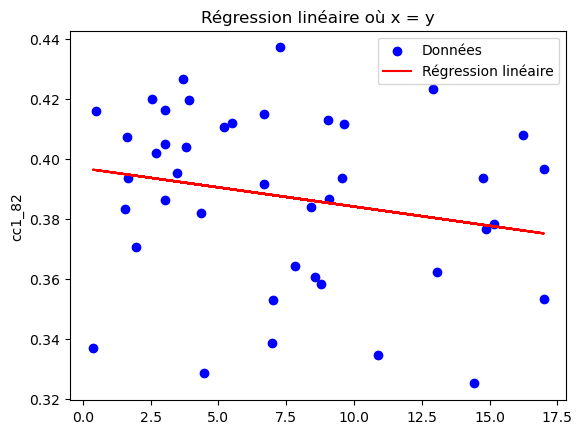

In [279]:
import statsmodels.api as sm

featid=7
cc=5
tgt_idx=1   ## 0 : feat select on age target, 1 : feat select on jnd target

y=jnd

df_matrices_cc1=pd.DataFrame(DTI[:,RFE_ranked_feat_allCC_tgt[cc-1][0][tgt_idx][0]<2,cc-1])
df_matrices_cc1.columns = ['cc1_'+str(x+1) for x in allbestfeat_cc[tgt_idx][cc-1]]

print(df_matrices_cc1.columns)
sns.scatterplot(x=y, y=df_matrices_cc1[df_matrices_cc1.columns[featid]])

x=y
y=df_matrices_cc1[df_matrices_cc1.columns[featid]]
x = sm.add_constant(x)

# Créer le modèle de régression linéaire
model = sm.OLS(y, x)
# Ajuster le modèle aux données
results = model.fit()
print(results.summary())

slope = results.params[1]
intercept = results.params[0]

# Créer une ligne de régression
regression_line = slope * x[:, 1] + intercept

# Tracer les points de données
plt.scatter(x[:, 1], y, color='blue', label='Données')
# Tracer la ligne de régression
plt.plot(x[:, 1], regression_line, color='red', label='Régression linéaire')


plt.title('Régression linéaire où x = y')
plt.legend()

# Afficher le graphique
plt.show()

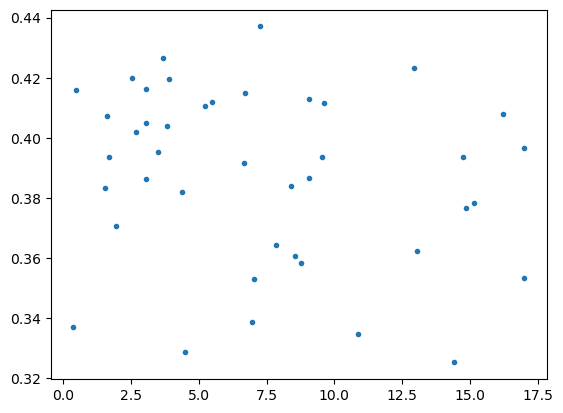

In [280]:
plt.plot(jnd, DTI[:,81,4],'.')

In [147]:
for tgt_idx, tgt in enumerate(target):
    print(f'Best features for target {tgt} :')
    for cc in range(7):
        print(np.where(RFE_ranked_feat_allCC_tgt[tgt_idx][cc]<2)[0].tolist())

last10from70_DTI

Best features for target age :


TypeError: '<' not supported between instances of 'list' and 'int'

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

nseeds=50

# Charger les données
MSEall = np.zeros((2,2,nseeds), dtype=object)  
MAEall = np.zeros((2,2,nseeds), dtype=object)

for tgt_idx, tgt in enumerate(target):

    if tgt=='age':
        y = age  # Target variable (dependent variable)
    elif tgt=='jnd':
        y = jnd  # Target variable (dependent variable)

    print(f'Processing target {tgt} with XGBRegressor for {nseeds} seeds')

    for bestfrom in [0,1]:    
        X = matrice_finale[bestfrom]   # Features (independent variable)

        for seed in range(nseeds):
                
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

            model = XGBRegressor()
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            # Évaluer le modèle
            MSEall[tgt_idx, bestfrom, seed] = mean_squared_error(y_test, predictions)
            MAEall[tgt_idx, bestfrom, seed] = mean_absolute_error(y_test, predictions)


Processing target age with XGBRegressor for 50 seeds
Processing target jnd with XGBRegressor for 50 seeds


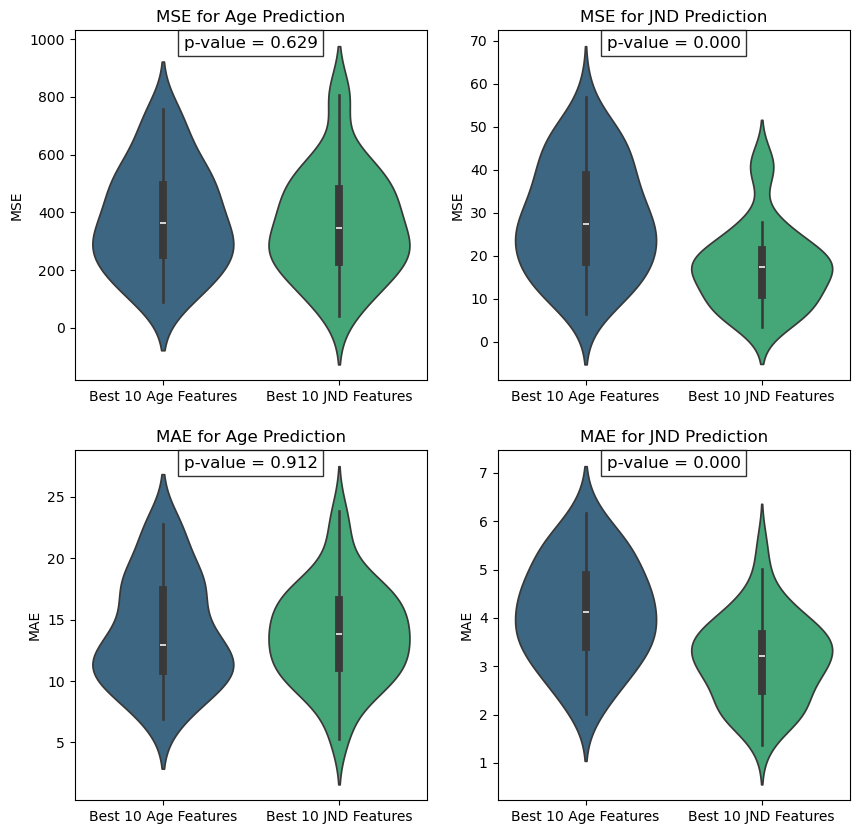

In [30]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

Metric_name=['MSE', 'MAE']

for metric_idx, metric in enumerate(Metric_name):
    if metric=='MSE':
        Metric_var=MSEall
    elif metric=='MAE':
        Metric_var=MAEall


    sns.violinplot(data=[Metric_var[0,0], Metric_var[0,1]],  palette='viridis', ax=axs[metric_idx,0])
    axs[metric_idx,0].set_title(f'{metric} for Age Prediction')
    axs[metric_idx,0].set_xticklabels(['Best 10 Age Features', 'Best 10 JND Features'])
    axs[metric_idx,0].set_ylabel(f'{metric}')

    sns.violinplot(data=[Metric_var[1,0], Metric_var[1,1]], palette='viridis', ax=axs[metric_idx,1])
    axs[metric_idx,1].set_title(f'{metric} for JND Prediction')
    axs[metric_idx,1].set_xticklabels(['Best 10 Age Features', 'Best 10 JND Features'])
    axs[metric_idx,1].set_ylabel(f'{metric}')

    from scipy.stats import kruskal


    statistic, p_value = kruskal(Metric_var[0,0], Metric_var[0,1])

    axs[metric_idx,0].text(0.5, 0.95, f'p-value = {p_value:.3f}',
                transform=axs[metric_idx,0].transAxes, ha='center', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8))



    statistic, p_value = kruskal(Metric_var[1,0], Metric_var[1,1])

    axs[metric_idx,1].text(0.5, 0.95, f'p-value = {p_value:.3f}',
                transform=axs[metric_idx,1].transAxes, ha='center', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8))


    

In [11]:
print(last10from70_DTI)
matrice_finale.shape

[[19. 29. 39. 43. 49. 53. 59. 63. 65. 69.]
 [ 8. 20. 26. 33. 36. 40. 43. 48. 53. 56.]]


(2, 47, 70)

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind


target=['jnd','age']  # 'age' or 'jnd'


for target in target:
    print("Target:", target)


    if target=='age':
            SelectedFeat=ranked_feat_allCC_tgt[0]
    elif target=='jnd':
            SelectedFeat=ranked_feat_allCC_tgt[1]
                            

    # CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

    figure, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))
    axs = axs.flatten()
    for CC in range(1,8):
            
        CCx=f'CC_{CC}'
        CCxindex=CC-1
        SelectedFeatonecc=SelectedFeat[CCxindex]


        axs[CCxindex].plot(DTI[:,:,CCxindex].T, color='lightgray', alpha=0.5)
        axs[CCxindex].plot(DTI[:,:,CCxindex].mean(axis=0), color='blue', linewidth=2)

        axs[CCxindex].plot(np.where(SelectedFeatonecc<5)[0],DTI[:,np.where(SelectedFeatonecc<5)[0],CCxindex].mean(axis=0), 'ro')

        axs[CCxindex].set_xlabel('Node index')
        axs[CCxindex].set_ylabel('FA')
        axs[CCxindex].grid(True)  
        axs[CCxindex].spines['top'].set_visible(False)
        axs[CCxindex].spines['right'].set_visible(False)
        axs[CCxindex].set_title(f'CC {CC} - Feature selection ')
        axs[CCxindex].set_title(CCx)

    figure.suptitle(f'Feature selection for target {target}', fontsize=16)

    axs[7].axis('off')
    plt.tight_layout(pad=2.0)


Target: jnd


NameError: name 'ranked_feat_allCC_tgt' is not defined